# Airbnb data cleaning

In this notebook we clean the Airbnb dataset from the class materials.

We keep the original CSV file unchanged. All changes are made only inside a pandas DataFrame called `df_clean`.

## 1. Import libraries and read the data

We start by importing the libraries used in class and reading the Airbnb dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt

from IPython.display import display

In [2]:
airbnb = pd.read_csv('../data/airbnb.csv', index_col='Unnamed: 0')
df_clean = airbnb.copy()

airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


## 2. Diagnosing data cleaning problems

Before cleaning the data, we check the basic structure of the DataFrame. This helps us find data type problems, missing values, strange categories, and possible out-of-range values.

In [3]:
airbnb.dtypes

listing_id              int64
name                      str
host_id                 int64
host_name                 str
neighbourhood_full        str
coordinates               str
room_type                 str
price                     str
number_of_reviews       int64
last_review               str
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added             str
dtype: object

In [4]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  str    
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  str    
 4   neighbourhood_full  10019 non-null  str    
 5   coordinates         10019 non-null  str    
 6   room_type           10019 non-null  str    
 7   price               9781 non-null   str    
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   str    
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  str    
dtypes: float64(4), 

In [5]:
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

In [6]:
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339


From these first checks, we can see a few problems:

- `coordinates` is text and should be split into latitude and longitude.
- `price` is text because it contains the `$` sign.
- `listing_added` and `last_review` should be date columns.
- `room_type` has spelling, spacing, and capitalization issues.
- `neighbourhood_full` contains both borough and neighbourhood.
- `rating` has a few values above 5.
- Some review columns have missing values.
- We should also check for duplicate records.

In [7]:
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

In [8]:
airbnb['room_type'].value_counts()

room_type
Entire home/apt         5120
Private room            4487
Shared room              155
Private                   89
   Shared room            71
home                      66
PRIVATE ROOM              31
Name: count, dtype: int64

In [9]:
airbnb['price'].head(10)

0     45$
1    135$
2    150$
3     86$
4    160$
5    150$
6    200$
7    224$
8    169$
9     75$
Name: price, dtype: str

### Missing data visualization

The columns connected with reviews have very similar missing values. This probably means that listings without reviews do not have a rating, last review date, or review statistics.

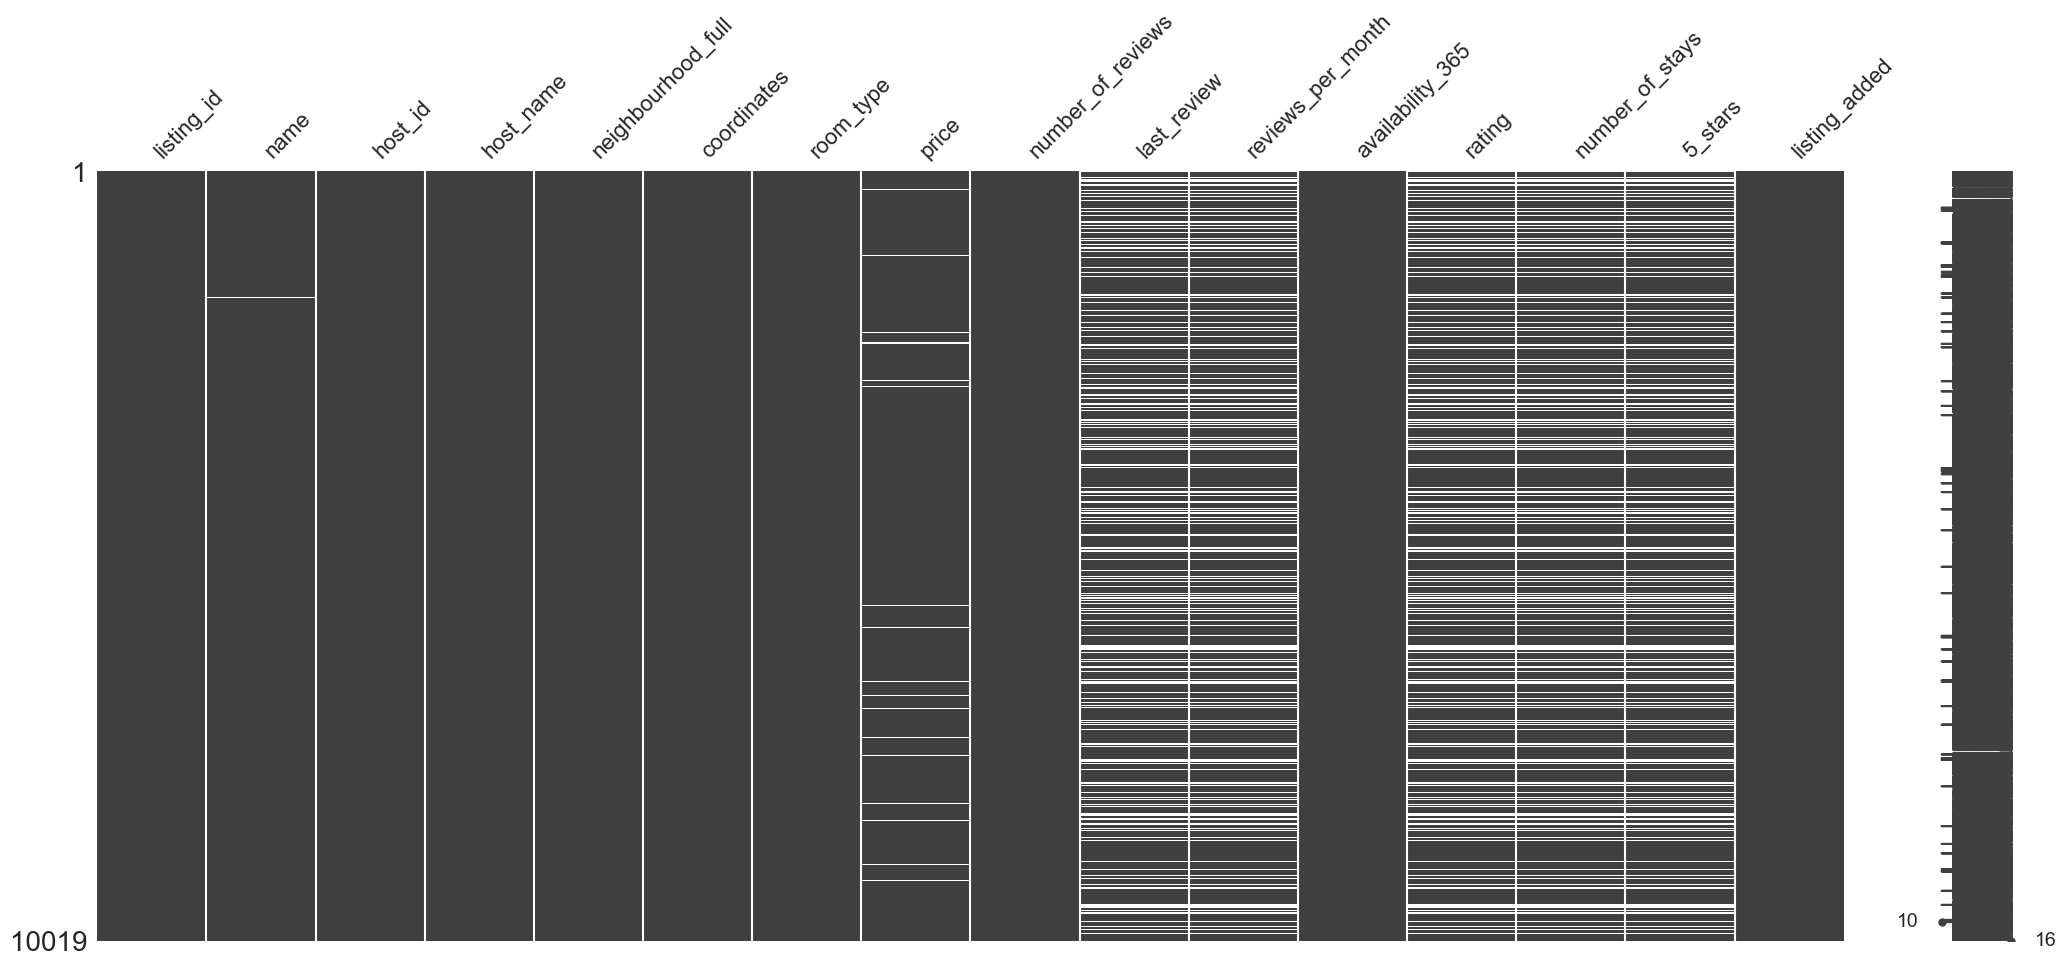

In [10]:
msno.matrix(airbnb)
plt.show()

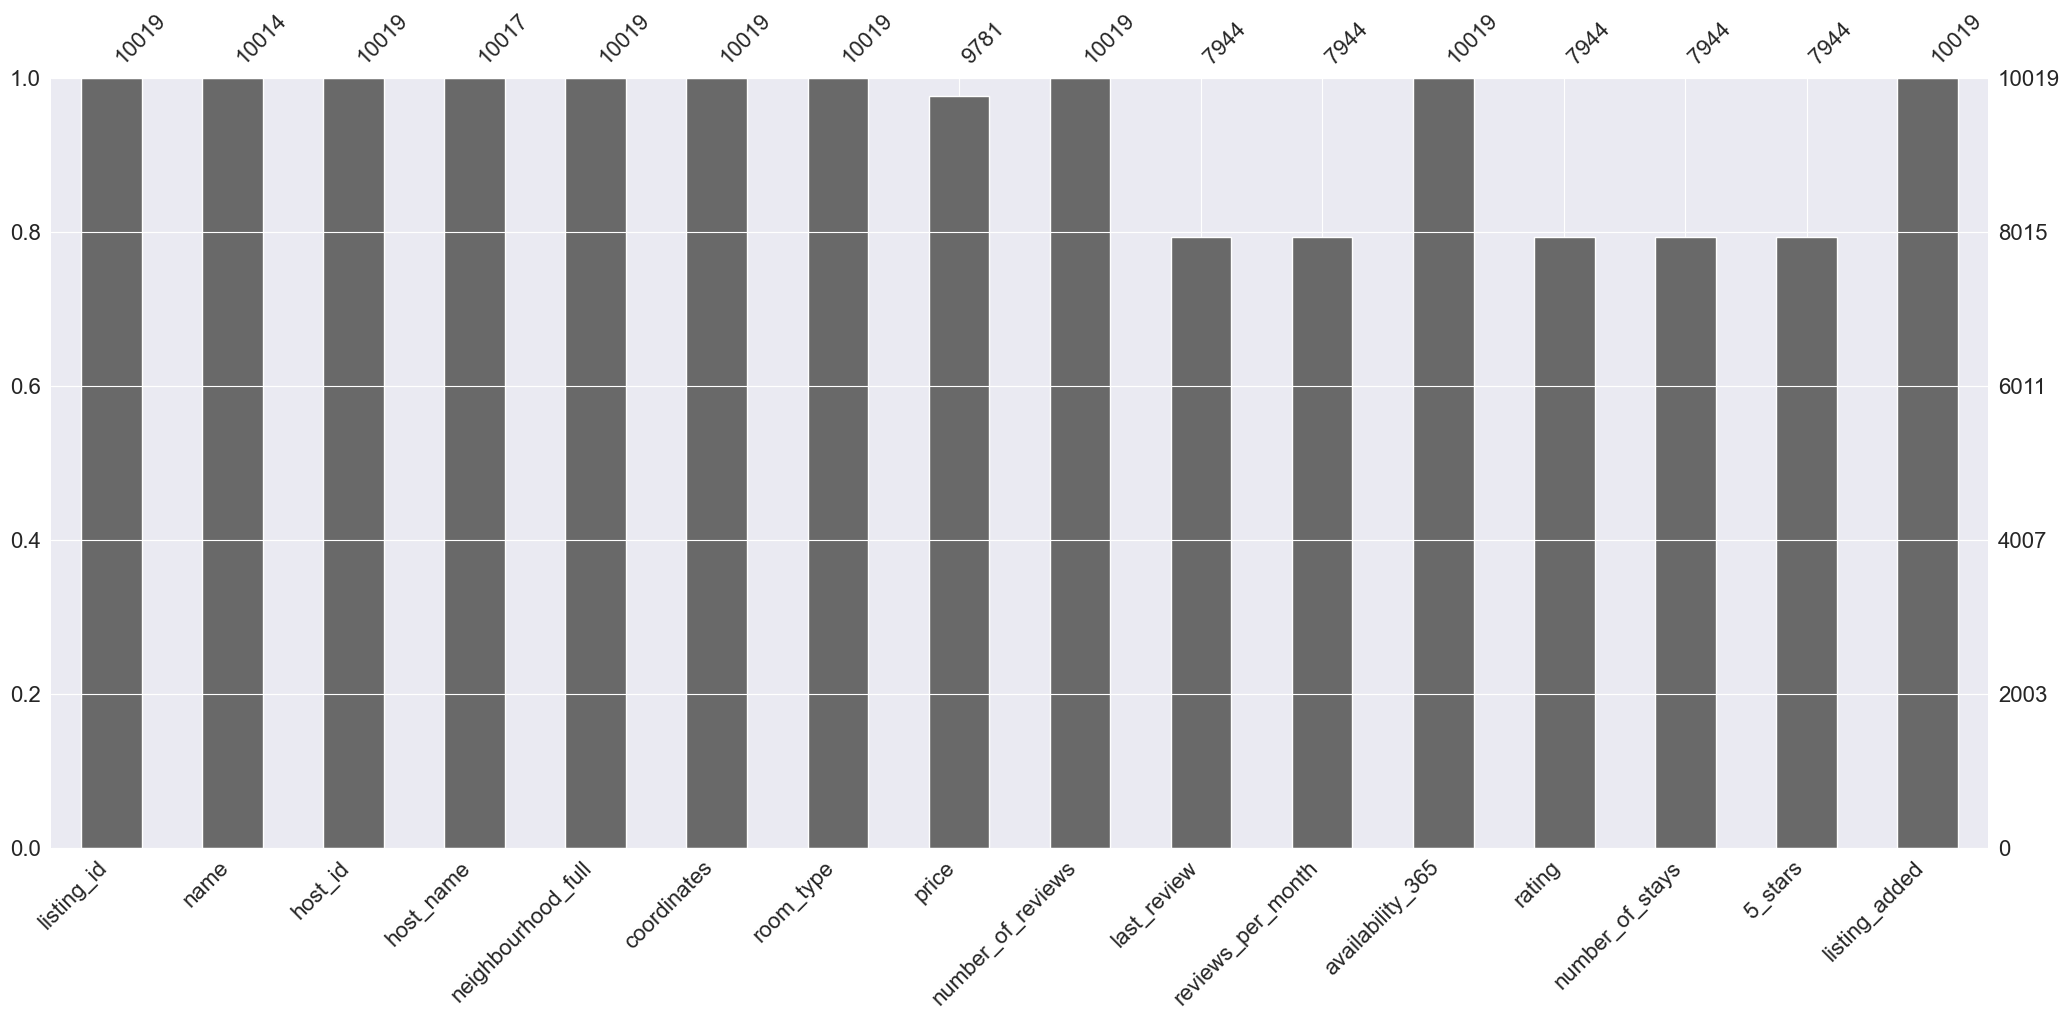

In [11]:
msno.bar(airbnb)
plt.show()

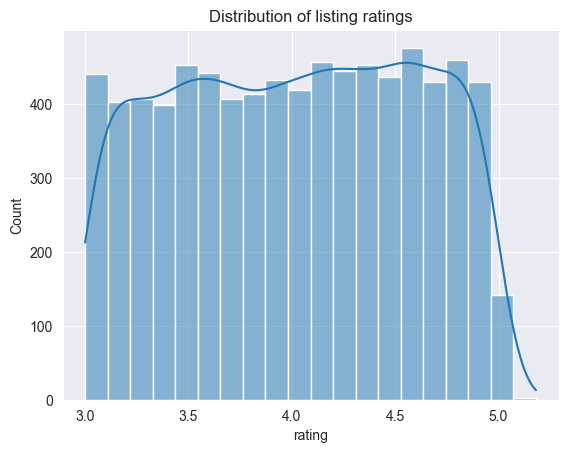

In [12]:
sns.histplot(airbnb['rating'], kde=True, bins=20)
plt.title('Distribution of listing ratings')
plt.show()

## 3. Cleaning data types

We start the cleaning from a fresh copy of the original DataFrame. This is useful because we can re-run this section while working in the notebook.

In [13]:
df_clean = airbnb.copy()

### Task 1: Split coordinates into latitude and longitude

The `coordinates` column contains two values in one string. We remove the brackets, split the string, and convert the new columns to float.

In [14]:
coordinates_split = (
    df_clean['coordinates']
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.split(',', expand=True)
)

df_clean['latitude'] = coordinates_split[0].str.strip().astype(float)
df_clean['longitude'] = coordinates_split[1].str.strip().astype(float)

df_clean = df_clean.drop(columns='coordinates')

df_clean[['latitude', 'longitude']].head()

,latitude,longitude
0,40.63222,-73.93398
1,40.78761,-73.96862
2,40.70070,-73.99517
3,40.79169,-73.97498
4,40.71884,-73.98354


### Task 2: Remove `$` from price and convert it to float

The `price` column should be numeric. We remove the dollar sign and convert the column to `float`. Prices equal to 0 are treated as missing values, because they do not make sense as nightly prices.

In [15]:
missing_price_before = df_clean['price'].isna().sum()
zero_price_before = (df_clean['price'].str.strip('$').astype(float) == 0).sum()

df_clean['price'] = df_clean['price'].str.strip('$')
df_clean['price'] = df_clean['price'].astype(float)

df_clean.loc[df_clean['price'] <= 0, 'price'] = np.nan

df_clean['price'].head()

0     45.0
1    135.0
2    150.0
3     86.0
4    160.0
Name: price, dtype: float64

### Task 3: Convert date columns

The date columns are converted to datetime format. This makes it possible to compare dates later.

In [16]:
df_clean['listing_added'] = pd.to_datetime(df_clean['listing_added'], format='%Y-%m-%d')
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], format='%Y-%m-%d')

df_clean[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaT
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [17]:
df_clean[['price', 'listing_added', 'last_review', 'latitude', 'longitude']].dtypes

price                   float64
listing_added    datetime64[us]
last_review      datetime64[us]
latitude                float64
longitude               float64
dtype: object

## 4. Cleaning text and categorical data

Now we clean text columns that will be useful for grouping and plotting.

### Task 4: Clean `room_type`

The `room_type` column has extra spaces, uppercase versions, and values that mean the same thing. We lowercase the text, remove spaces, and then replace the values with cleaner categories.

In [18]:
df_clean['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

In [19]:
df_clean['room_type'] = df_clean['room_type'].str.lower()
df_clean['room_type'] = df_clean['room_type'].str.strip()

df_clean['room_type'].unique()

<StringArray>
['private room', 'entire home/apt', 'private', 'shared room', 'home']
Length: 5, dtype: str

In [20]:
room_type_mapping = {
    'private room': 'Private Room',
    'private': 'Private Room',
    'entire home/apt': 'Entire place',
    'home': 'Entire place',
    'shared room': 'Shared Room'
}

df_clean['room_type'] = df_clean['room_type'].replace(room_type_mapping)

df_clean['room_type'].value_counts()

room_type
Entire place    5186
Private Room    4607
Shared Room      226
Name: count, dtype: int64

### Task 5: Split borough and neighbourhood

The `neighbourhood_full` column contains borough and neighbourhood in one column. We split it into two separate columns.

In [21]:
neighbourhood_split = df_clean['neighbourhood_full'].str.split(',', expand=True)

df_clean['borough'] = neighbourhood_split[0].str.strip()
df_clean['neighbourhood'] = neighbourhood_split[1].str.strip()

df_clean = df_clean.drop(columns='neighbourhood_full')

df_clean[['borough', 'neighbourhood']].head()

,borough,neighbourhood
0,Brooklyn,Flatlands
1,Manhattan,Upper West Side
2,Brooklyn,Brooklyn Heights
3,Manhattan,Upper West Side
4,Manhattan,Lower East Side


## 5. Cleaning out-of-range data

The rating should be between 0 and 5. There are a few values above 5, so we replace them with 5.

In [22]:
rating_above_5 = (df_clean['rating'] > 5).sum()

print('Ratings above 5 before cleaning:', rating_above_5)

df_clean.loc[df_clean['rating'] > 5, 'rating'] = 5

print('Maximum rating after cleaning:', df_clean['rating'].max())

Ratings above 5 before cleaning: 3
Maximum rating after cleaning: 5.0


## 6. Treating missing data

The missing review information mostly appears when `number_of_reviews` is 0. This means that the listing has not been reviewed yet.

For these listings, we set `reviews_per_month`, `number_of_stays`, and `5_stars` to 0. We keep `rating` missing because no rating was actually given. We also create an `is_rated` column.

In [23]:
df_clean[df_clean['rating'].isna()]['number_of_reviews'].value_counts()

number_of_reviews
0    2075
Name: count, dtype: int64

In [24]:
df_clean = df_clean.fillna({
    'reviews_per_month': 0,
    'number_of_stays': 0,
    '5_stars': 0
})

df_clean['is_rated'] = np.where(df_clean['rating'].isna(), 0, 1)

df_clean[['number_of_reviews', 'reviews_per_month', 'number_of_stays', '5_stars', 'rating', 'is_rated']].head()

,number_of_reviews,reviews_per_month,number_of_stays,5_stars,rating,is_rated
0,10,0.70,12.0,0.609432,4.100954,1
1,1,1.00,1.2,0.746135,3.367600,1
2,0,0.00,0.0,0.000000,NaN,0
3,5,0.13,6.0,0.769947,4.763203,1
4,23,2.29,27.6,0.649383,3.822591,1


### Treating missing prices

For missing prices, we use the median price for each `room_type`. This is a simple method and it makes sense because room type is connected with price.

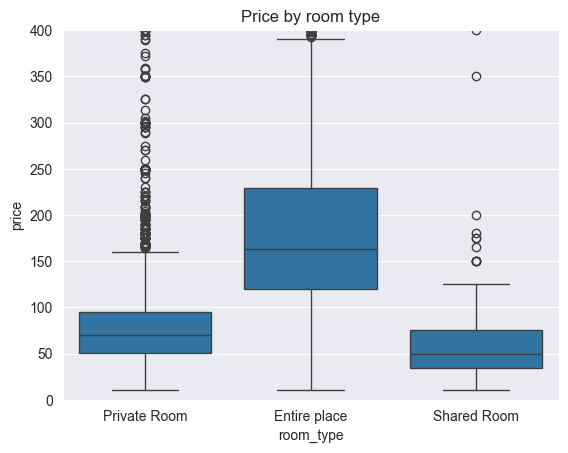

In [25]:
sns.boxplot(x='room_type', y='price', data=df_clean)
plt.ylim(0, 400)
plt.title('Price by room type')
plt.show()

In [26]:
median_price_by_room_type = df_clean.groupby('room_type')['price'].median()
median_price_by_room_type

room_type
Entire place    163.0
Private Room     70.0
Shared Room      50.0
Name: price, dtype: float64

In [27]:
df_clean['price'] = df_clean['price'].fillna(df_clean['room_type'].map(median_price_by_room_type))

df_clean['price'].isna().sum()

np.int64(0)

### Small text missing values

There are only a few missing values in `name` and `host_name`. We replace them with simple labels so they do not appear as empty values later.

In [28]:
df_clean['name'] = df_clean['name'].fillna('Unknown listing')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown host')

df_clean[['name', 'host_name']].isna().sum()

name         0
host_name    0
dtype: int64

## 7. Checking date consistency

Dates should be logical. We check if there are listings or reviews in the future and if any listing was added after its last review.

In [29]:
today = dt.date.today()

future_listings = df_clean[df_clean['listing_added'].dt.date > today]
future_reviews = df_clean[df_clean['last_review'].dt.date > today]

print('Listings added in the future:', len(future_listings))
print('Reviews in the future:', len(future_reviews))

Listings added in the future: 0
Reviews in the future: 0


In [30]:
inconsistent_dates = df_clean[df_clean['listing_added'].dt.date > df_clean['last_review'].dt.date]

inconsistent_dates[['listing_id', 'name', 'listing_added', 'last_review']]

,listing_id,name,listing_added,last_review
4,22986519,Bedroom on the lively Lower East Side,2020-10-23,2019-06-12
50,20783900,Marvelous Manhattan Marble Hill Private Suites,2020-02-17,2018-10-06
60,1908852,Oversized Studio By Columbus Circle,2017-09-17,2016-05-06
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,2020-08-23,2019-04-12
511,33619855,Modern & Spacious in trendy Crown Heights,2020-10-07,2019-05-27
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,2020-10-22,2019-06-11


In [31]:
df_clean = df_clean.drop(inconsistent_dates.index)

print('Rows after removing inconsistent dates:', len(df_clean))

Rows after removing inconsistent dates: 10013


## 8. Checking duplicates

We check two duplicate problems:

1. fully identical rows,
2. repeated `listing_id` values.

We do not remove rows just because they have the same price. Different listings can have the same price, and that is normal.

In [32]:
exact_duplicates = df_clean.duplicated().sum()
print('Fully duplicated rows:', exact_duplicates)

df_clean = df_clean.drop_duplicates()

Fully duplicated rows: 13


In [33]:
duplicated_listing_ids = df_clean[df_clean.duplicated(subset='listing_id', keep=False)].sort_values('listing_id')

duplicated_listing_ids.head(10)

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,250.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,245.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,70.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,73.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,289.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,280.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,154.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,150.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
1481,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.969729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1
3430,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.869729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1


For repeated `listing_id` values, we combine the records. For most columns we keep the first value. For price and rating we use the mean, and for dates we keep the latest date.

In [34]:
rows_before_listing_id_cleaning = len(df_clean)

aggregation_rules = {column: 'first' for column in df_clean.columns if column != 'listing_id'}

aggregation_rules.update({
    'price': 'mean',
    'rating': 'mean',
    'listing_added': 'max',
    'last_review': 'max',
    'number_of_reviews': 'max',
    'reviews_per_month': 'mean',
    'number_of_stays': 'mean',
    '5_stars': 'mean',
    'availability_365': 'max',
    'is_rated': 'max'
})

df_clean = df_clean.groupby('listing_id', as_index=False).agg(aggregation_rules)

print('Rows merged by listing_id:', rows_before_listing_id_cleaning - len(df_clean))
print('Is listing_id unique now?', df_clean['listing_id'].is_unique)

Rows merged by listing_id: 7
Is listing_id unique now? True


## 9. Final check

At the end we check the cleaned DataFrame again. Some missing values are still expected, especially `rating` and `last_review` for listings without reviews.

In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   listing_id         9993 non-null   int64         
 1   name               9993 non-null   str           
 2   host_id            9993 non-null   int64         
 3   host_name          9993 non-null   str           
 4   room_type          9993 non-null   str           
 5   price              9993 non-null   float64       
 6   number_of_reviews  9993 non-null   int64         
 7   last_review        7922 non-null   datetime64[us]
 8   reviews_per_month  9993 non-null   float64       
 9   availability_365   9993 non-null   int64         
 10  rating             7922 non-null   float64       
 11  number_of_stays    9993 non-null   float64       
 12  5_stars            9993 non-null   float64       
 13  listing_added      9993 non-null   datetime64[us]
 14  latitude           

In [36]:
df_clean.isna().sum()

listing_id              0
name                    0
host_id                 0
host_name               0
room_type               0
price                   0
number_of_reviews       0
last_review          2071
reviews_per_month       0
availability_365        0
rating               2071
number_of_stays         0
5_stars                 0
listing_added           0
latitude                0
longitude               0
borough                 0
neighbourhood           0
is_rated                0
dtype: int64

In [37]:
print('Original shape:', airbnb.shape)
print('Cleaned shape:', df_clean.shape)

summary = pd.DataFrame({
    'step': [
        'missing prices before cleaning',
        'zero prices treated as missing',
        'ratings above 5 corrected',
        'rows with inconsistent dates removed',
        'fully duplicated rows removed',
        'rows merged by listing_id'
    ],
    'count': [
        missing_price_before,
        zero_price_before,
        rating_above_5,
        len(inconsistent_dates),
        exact_duplicates,
        rows_before_listing_id_cleaning - len(df_clean)
    ]
})

summary

Original shape: (10019, 16)
Cleaned shape: (9993, 19)


,step,count
0,missing prices before cleaning,238
1,zero prices treated as missing,2
2,ratings above 5 corrected,3
3,rows with inconsistent dates removed,6
4,fully duplicated rows removed,13
5,rows merged by listing_id,7


In [38]:
df_clean.head()

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Entire place,89.0,270,2019-07-05,4.64,194,3.273935,324.0,0.757366,2018-12-30,40.68514,-73.95976,Brooklyn,Clinton Hill,1
1,6848,Only 2 stops to Manhattan studio,15991,Allen & Irina,Entire place,140.0,148,2019-06-29,1.20,46,3.495760,177.6,0.789743,2018-12-24,40.70837,-73.95352,Brooklyn,Williamsburg,1
2,7322,Chelsea Perfect,18946,Doti,Private Room,140.0,260,2019-07-01,2.12,12,4.389051,312.0,0.669873,2018-12-26,40.74192,-73.99501,Manhattan,Chelsea,1
3,7726,Hip Historic Brownstone Apartment with Backyard,20950,Adam And Charity,Entire place,99.0,53,2019-06-22,4.44,21,3.305382,63.6,0.640251,2018-12-17,40.67592,-73.94694,Brooklyn,Crown Heights,1
4,12303,1bdr w private bath. in lofty apt,47618,Yolande,Private Room,120.0,25,2018-09-30,0.23,311,4.568745,30.0,0.918593,2018-03-27,40.69673,-73.97584,Brooklyn,Fort Greene,1


## 10. Summary of cleaning

In this notebook we cleaned the Airbnb dataset by doing the following:

- split `coordinates` into `latitude` and `longitude`,
- converted `price` from text to numeric values,
- converted `listing_added` and `last_review` to dates,
- cleaned the `room_type` categories,
- split `neighbourhood_full` into `borough` and `neighbourhood`,
- capped ratings above 5,
- filled review-related missing values with 0 when listings had no reviews,
- filled missing prices using median price by room type,
- filled small text missing values in `name` and `host_name`,
- removed rows with inconsistent dates,
- removed fully duplicated rows,
- merged repeated listings with the same `listing_id`.

The original CSV file was not changed. All cleaning was done in the `df_clean` DataFrame.